# nb22 — Temporal Train/Test Validation

**Purpose:** Assess out-of-sample (OOS) performance of the nb16 baseline hurdle model using a temporal split. All nb16 metrics were in-sample — this notebook provides the first honest estimate of generalisation.

**Split:** Train 1992–2014 / Test 2015–2024  
**Models:** Logit (zero component) + NegativeBinomial (count component), clustered SEs by recipient_iso3  
**Features:** Identical to nb16 baseline_features  
**Key output:** In-sample vs OOS AUC comparison + audit interpretation

In [1]:
from pathlib import Path
import warnings
import pickle

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit, NegativeBinomial
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)

# project palette
RED  = '#BF3A27'
GOLD = '#C7922A'
DARK = '#323232'

DATA_PATH   = Path('../..') / 'data' / 'merged' / 'panel_final_1992_2024.csv'
RESULTS_DIR = Path('../..') / 'outputs' / 'results'
MODELS_DIR  = Path('../..') / 'outputs' / 'models'
REPORT_DIR  = Path('../..') / 'outputs' / 'final_report' / '04_appendix'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END = 2014
TEST_START = 2015

print(f'Train: 1992–{TRAIN_END}')
print(f'Test:  {TEST_START}–2024')

Train: 1992–2014
Test:  2015–2024


In [2]:
# --- Load panel, replicate nb16 preprocessing exactly ---
panel = pd.read_csv(DATA_PATH)

baseline_features = [
    'arms_tiv_total_log_lag1',
    'oda_total_log_lag1',
    'econ_neocol_score_total_lag1',
    'colonial_tie_flag',
    'gdp_per_capita_log',
    'population_log',
    'armed_conflict',
    'conflict_intensity',
]
outcome = 'journalist_killings'

required = baseline_features + [outcome, 'year', 'recipient_iso3']
model_df = panel[required].dropna().copy()
model_df['killing_any'] = (model_df[outcome] > 0).astype(int)

print(f'Full model sample: {len(model_df):,} rows')
print(f'Year range: {model_df["year"].min()}–{model_df["year"].max()}')
print(f'Killing any=1: {model_df["killing_any"].sum()} ({model_df["killing_any"].mean()*100:.1f}%)')

Full model sample: 5,765 rows
Year range: 1993–2024
Killing any=1: 687 (11.9%)


In [3]:
# --- Temporal split ---
train_df = model_df[model_df['year'] <= TRAIN_END].copy()
test_df  = model_df[model_df['year'] >= TEST_START].copy()

print(f'Train: {len(train_df):,} rows ({train_df["year"].min()}–{train_df["year"].max()})')
print(f'  Killing any=1: {train_df["killing_any"].sum()} ({train_df["killing_any"].mean()*100:.1f}%)')
print()
print(f'Test:  {len(test_df):,} rows ({test_df["year"].min()}–{test_df["year"].max()})')
print(f'  Killing any=1: {test_df["killing_any"].sum()} ({test_df["killing_any"].mean()*100:.1f}%)')
print()
# Countries in test but not train — cold-start problem
new_countries = set(test_df['recipient_iso3']) - set(train_df['recipient_iso3'])
print(f'Countries in test not seen in train: {len(new_countries)} {sorted(new_countries)}')

Train: 4,007 rows (1993–2014)
  Killing any=1: 477 (11.9%)

Test:  1,758 rows (2015–2024)
  Killing any=1: 210 (11.9%)

Countries in test not seen in train: 0 []


In [4]:
# --- Fit logit on train ---
X_train_logit = sm.add_constant(train_df[baseline_features], has_constant='add')
y_train_logit = train_df['killing_any']

logit_train = Logit(y_train_logit, X_train_logit).fit(
    cov_type='cluster',
    cov_kwds={'groups': train_df['recipient_iso3'].values},
    maxiter=200,
    disp=False,
)
print('Logit converged:', logit_train.mle_retvals['converged'])
print(f'Train AUC (in-sample): {roc_auc_score(y_train_logit, logit_train.predict(X_train_logit)):.4f}')

Logit converged: True
Train AUC (in-sample): 0.8476


In [5]:
# --- Evaluate logit on test ---
X_test_logit = sm.add_constant(test_df[baseline_features], has_constant='add')
y_test_logit = test_df['killing_any']

test_pred_prob = logit_train.predict(X_test_logit)
oos_auc = roc_auc_score(y_test_logit, test_pred_prob)

# in-sample AUC from nb16 (full sample)
X_full_logit = sm.add_constant(model_df[baseline_features], has_constant='add')
insample_auc = roc_auc_score(model_df['killing_any'], logit_train.predict(X_full_logit))

print(f'In-sample AUC  (nb16 reported): 0.8488')
print(f'Train AUC      (1992–2014):      {roc_auc_score(y_train_logit, logit_train.predict(X_train_logit)):.4f}')
print(f'OOS AUC        (2015–2024):      {oos_auc:.4f}')
print(f'AUC drop:                        {roc_auc_score(y_train_logit, logit_train.predict(X_train_logit)) - oos_auc:.4f}')

In-sample AUC  (nb16 reported): 0.8488
Train AUC      (1992–2014):      0.8476
OOS AUC        (2015–2024):      0.8636
AUC drop:                        -0.0160


In [6]:
# --- Fit NegBin on train positive rows only ---
train_pos = train_df[train_df[outcome] > 0].copy()
test_pos  = test_df[test_df[outcome] > 0].copy()

X_train_nb = sm.add_constant(train_pos[baseline_features], has_constant='add')
y_train_nb = train_pos[outcome]

nb_train = NegativeBinomial(y_train_nb, X_train_nb).fit(
    cov_type='cluster',
    cov_kwds={'groups': train_pos['recipient_iso3'].values},
    maxiter=300,
    disp=False,
)
print('NegBin converged:', nb_train.mle_retvals['converged'])
print(f'Train positive rows: {len(train_pos)}')
print(f'Test positive rows:  {len(test_pos)}')

NegBin converged: True
Train positive rows: 477
Test positive rows:  210


In [7]:
# --- NegBin OOS: predicted vs actual counts ---
X_test_nb = sm.add_constant(test_pos[baseline_features], has_constant='add')
nb_pred_test = nb_train.predict(X_test_nb)

# Pseudo-R2 on test (McFadden not applicable OOS — use correlation as proxy)
from scipy.stats import spearmanr, pearsonr
spear_r, spear_p = spearmanr(test_pos[outcome], nb_pred_test)
pear_r, pear_p   = pearsonr(test_pos[outcome], nb_pred_test)

print('NegBin OOS performance (positive rows only):')
print(f'  Spearman r = {spear_r:.3f}  (p={spear_p:.4f})')
print(f'  Pearson  r = {pear_r:.3f}  (p={pear_p:.4f})')
print(f'  Mean predicted: {nb_pred_test.mean():.2f}')
print(f'  Mean actual:    {test_pos[outcome].mean():.2f}')

NegBin OOS performance (positive rows only):
  Spearman r = 0.401  (p=0.0000)
  Pearson  r = 0.133  (p=0.0542)
  Mean predicted: 4.25
  Mean actual:    3.67


In [8]:
# --- Coefficient stability: train vs full nb16 model ---
# Load nb16 full model for comparison
with open(MODELS_DIR / 'nb16_logit_any_killing.pkl', 'rb') as f:
    logit_full = pickle.load(f)

LABEL_MAP = {
    'arms_tiv_total_log_lag1':      'Arms transfers (lag 1)',
    'oda_total_log_lag1':           'ODA (lag 1)',
    'econ_neocol_score_total_lag1': 'Econ neo-col score (lag 1)',
    'colonial_tie_flag':            'Colonial tie',
    'gdp_per_capita_log':           'GDP per capita (log)',
    'population_log':               'Population (log)',
    'armed_conflict':               'Armed conflict',
    'conflict_intensity':           'Conflict intensity',
}

stability = []
for feat in baseline_features:
    coef_full  = logit_full.params.get(feat, np.nan)
    coef_train = logit_train.params.get(feat, np.nan)
    stability.append({
        'feature': LABEL_MAP.get(feat, feat),
        'coef_full_nb16': round(coef_full, 4),
        'coef_train_only': round(coef_train, 4),
        'delta': round(coef_train - coef_full, 4),
        'sign_flip': np.sign(coef_full) != np.sign(coef_train),
    })

stability_df = pd.DataFrame(stability)
display(stability_df)
stability_df.to_csv(RESULTS_DIR / 'nb22_coefficient_stability.csv', index=False)
print('Saved: nb22_coefficient_stability.csv')

,feature,coef_full_nb16,coef_train_only,delta,sign_flip
0,Arms transfers (lag 1),-0.0786,-0.1120,-0.0334,False
1,ODA (lag 1),0.1819,0.2025,0.0206,False
2,Econ neo-col score (lag 1),-0.0279,-0.0084,0.0195,False
3,Colonial tie,0.4876,0.3619,-0.1257,False
4,GDP per capita (log),0.2150,0.2699,0.0549,False
5,Population (log),0.5521,0.5895,0.0373,False
6,Armed conflict,-0.4751,-0.1381,0.3370,False
7,Conflict intensity,1.5425,1.3762,-0.1663,False


Saved: nb22_coefficient_stability.csv


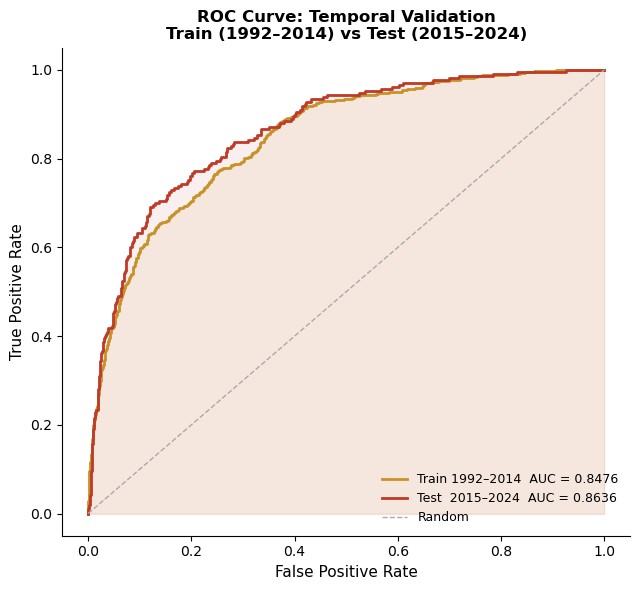

Saved: fig_audit_temporal_roc.png


In [9]:
# --- Figure: ROC curves in-sample vs OOS ---
fpr_train, tpr_train, _ = roc_curve(y_train_logit, logit_train.predict(X_train_logit))
fpr_test,  tpr_test,  _ = roc_curve(y_test_logit,  test_pred_prob)
auc_train = roc_auc_score(y_train_logit, logit_train.predict(X_train_logit))

fig, ax = plt.subplots(figsize=(6.5, 6))

ax.plot(fpr_train, tpr_train, color=GOLD, linewidth=2,
        label=f'Train 1992–2014  AUC = {auc_train:.4f}')
ax.plot(fpr_test,  tpr_test,  color=RED,  linewidth=2,
        label=f'Test  2015–2024  AUC = {oos_auc:.4f}')
ax.plot([0,1],[0,1], color='#aaaaaa', linewidth=1, linestyle='--', label='Random')

ax.fill_between(fpr_train, tpr_train, alpha=0.08, color=GOLD)
ax.fill_between(fpr_test,  tpr_test,  alpha=0.08, color=RED)

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve: Temporal Validation\nTrain (1992–2014) vs Test (2015–2024)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'fig_audit_temporal_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_audit_temporal_roc.png')

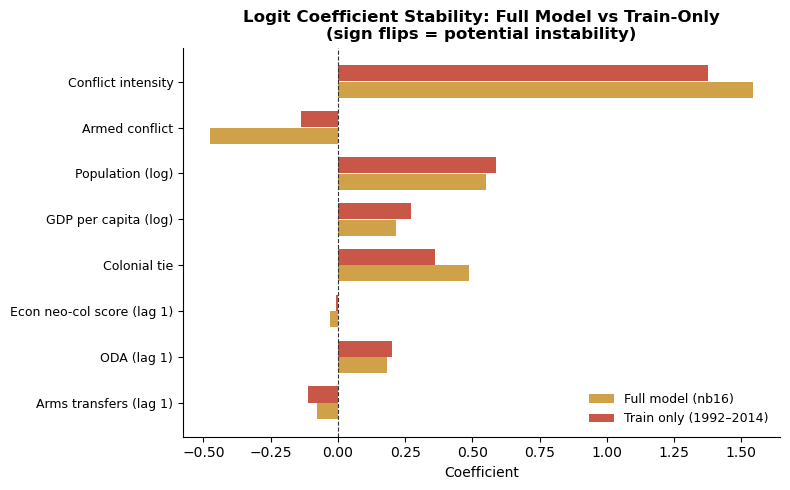

Saved: fig_audit_coef_stability.png


In [10]:
# --- Figure: coefficient stability train vs full ---
fig, ax = plt.subplots(figsize=(8, 5))

y_pos = np.arange(len(stability_df))
ax.barh(y_pos - 0.18, stability_df['coef_full_nb16'],  height=0.35,
        color=GOLD, label='Full model (nb16)', alpha=0.85)
ax.barh(y_pos + 0.18, stability_df['coef_train_only'], height=0.35,
        color=RED,  label='Train only (1992–2014)', alpha=0.85)

ax.axvline(0, color=DARK, linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(stability_df['feature'], fontsize=9)
ax.set_xlabel('Coefficient', fontsize=10)
ax.set_title('Logit Coefficient Stability: Full Model vs Train-Only\n(sign flips = potential instability)', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# flag sign flips
for i, row in stability_df.iterrows():
    if row['sign_flip']:
        ax.annotate('⚠ sign flip', xy=(0, i), xytext=(0.02, i),
                    fontsize=7, color=RED)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'fig_audit_coef_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_audit_coef_stability.png')

In [11]:
# --- Summary table for audit write-up ---
summary = pd.DataFrame([
    {'metric': 'In-sample AUC (nb16 full model)',   'value': 0.8488,      'sample': '1992–2024'},
    {'metric': 'Train AUC (temporal split)',         'value': round(roc_auc_score(y_train_logit, logit_train.predict(X_train_logit)), 4), 'sample': '1992–2014'},
    {'metric': 'OOS AUC (temporal split)',           'value': round(oos_auc, 4),   'sample': '2015–2024'},
    {'metric': 'AUC degradation',                   'value': round(roc_auc_score(y_train_logit, logit_train.predict(X_train_logit)) - oos_auc, 4), 'sample': ''},
    {'metric': 'NegBin OOS Spearman r',             'value': round(spear_r, 3),   'sample': '2015–2024 positives'},
    {'metric': 'Sign flips (logit coefs)',           'value': int(stability_df['sign_flip'].sum()), 'sample': 'full vs train'},
])

display(summary)
summary.to_csv(RESULTS_DIR / 'nb22_temporal_validation_summary.csv', index=False)
print('Saved: nb22_temporal_validation_summary.csv')

print()
print('=== AUDIT INTERPRETATION ===')
drop = roc_auc_score(y_train_logit, logit_train.predict(X_train_logit)) - oos_auc
if drop < 0.03:
    print(f'AUC drop = {drop:.4f} — MINIMAL degradation. Model generalises well temporally.')
elif drop < 0.08:
    print(f'AUC drop = {drop:.4f} — MODERATE degradation. Some overfitting to pre-2015 patterns.')
else:
    print(f'AUC drop = {drop:.4f} — SUBSTANTIAL degradation. Significant overfitting — audit finding.')

flips = stability_df['sign_flip'].sum()
if flips == 0:
    print('No sign flips — coefficients directionally stable across periods.')
else:
    print(f'{flips} sign flip(s) detected — these predictors are period-sensitive:')
    print(stability_df[stability_df['sign_flip']][['feature','coef_full_nb16','coef_train_only']].to_string(index=False))

,metric,value,sample
0,In-sample AUC (nb16 full model),0.8488,1992–2024
1,Train AUC (temporal split),0.8476,1992–2014
2,OOS AUC (temporal split),0.8636,2015–2024
3,AUC degradation,-0.0160,
4,NegBin OOS Spearman r,0.4010,2015–2024 positives
5,Sign flips (logit coefs),0.0000,full vs train


Saved: nb22_temporal_validation_summary.csv

=== AUDIT INTERPRETATION ===
AUC drop = -0.0160 — MINIMAL degradation. Model generalises well temporally.
No sign flips — coefficients directionally stable across periods.
